# 8.4 From Text to Vectors: Tokens, One-Hot, and Embeddings

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter VIII — The Linear Algebra of Learning",
    number="8.4",
    title="From Text to Vectors: Tokens, One-Hot, and Embeddings",
    blurb="Language enters linear algebra through three doors: a tokenizer "
    "chops strings into integers, an embedding matrix turns integers into "
    "vectors — a matrix product nobody actually performs — and factored "
    "count matrices give the vectors their geometry, where king minus man "
    "plus woman lands nearest queen, gated like everything else.",
    difficulty="advanced",
    estimate="135–165 min",
)

<ECP header: 2675 chars of HTML>

## Notebook overview

Before a transformer can multiply matrices, text must become numbers,
and every step of that conversion is this course's material. A
**byte-pair-encoding** merge loop {cite}`sennrich2016bpe` — written by
hand, with a stated tie-break so the merges are deterministic — builds
a subword vocabulary whose decoding reproduces the input *exactly*
(gated as string equality, the format rule of
[§5.3](../05-numerical/sparse-matrices.ipynb) applied to text). Token
IDs become **one-hot vectors** — the standard basis wearing
linguistics — and the embedding lookup is gated as the matrix product
it secretly is: $e_i^{\top}E$ equals row $E_i$ *exactly*, because a
one-hot product sums nothing but exact zeros and one exact copy; the
ledger (2Vd flops for the product, d copied numbers for the lookup —
a counted $2V\times$ asymmetry, stopwatch reported per the course's
rules) is why no framework ever forms the one-hot.

Geometry arrives through counts. The **term–document matrix** of a
twelve-document, three-topic corpus gets the TF-IDF reweighting
(gated against its closed form), and **LSA** {cite}`deerwester1990` —
a truncated SVD, [§4.3](../04-svd/pca-covariance-whitening.ipynb)'s
machinery verbatim — recovers the planted topics *exactly* by
nearest-centroid in two dimensions. **PPMI factorization**
{cite}`levy2014` — the linear algebra word2vec implicitly performs —
builds an eight-word royal-family micro-world where the analogy
$\textit{king} - \textit{man} + \textit{woman}$ lands nearest
*queen* (gated, query words excluded, margin 0.13 over the
runner-up), drawn as the parallelogram it algebraically is. The
closing measurement is the one that governs all of retrieval: random
high-dimensional cosines concentrate near zero at the $1/\sqrt{d}$
rate — measured at three dimensions on a dedicated stream — which is
*why* similarity search works at all in embedding spaces.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Sennrich et al. {cite}`sennrich2016bpe` for BPE;
> Deerwester et al. {cite}`deerwester1990` for LSA; Levy and Goldberg
> {cite}`levy2014` for the PPMI–word2vec equivalence. The SVD is
> Chapter IV's; nothing here needs a GPU or a download.

## Theory in brief

### Tokens, one-hots, and the lookup identity

BPE starts from characters and greedily merges the most frequent
adjacent pair, $k$ times; the merges *are* the vocabulary. A token ID
$i$ is the standard basis vector $e_i \in \mathbb{R}^{V}$, and the
embedding of a token is

```{math}
:label: eq-tv-lookup
\operatorname{embed}(i) \;=\; e_i^{\top}E \;=\; E_{i,:} ,
```

a matrix product whose result is a *row copy* — the identity every
framework exploits by never forming $e_i$: the product costs $2Vd$
operations to select what indexing copies in $d$.

### Counts, reweighted and factored

The term–document matrix $C_{wj}$ counts word $w$ in document $j$;
TF-IDF reweights it,

```{math}
:label: eq-tv-tfidf
X_{wj} \;=\; \frac{C_{wj}}{\sum_w C_{wj}}\;
\log\frac{N}{\lvert\{j : C_{wj} > 0\}\rvert} ,
```

damping ubiquitous words. LSA is its truncated SVD: documents in the
top singular directions, topics as the directions themselves.
**PPMI** does the same for word–context co-occurrence,

```{math}
:label: eq-tv-ppmi
\mathrm{PPMI}_{wc} \;=\; \max\!\Bigl(0,\;
\log\frac{P(w,c)}{P(w)P(c)}\Bigr),
```

and its truncated SVD produces word vectors equivalent (Levy–Goldberg)
to what skip-gram training approximates — analogies as
parallelograms, similarity as cosine.

### Why cosine works in high dimension

Independent random vectors in $\mathbb{R}^d$ have
$\mathbb{E}\lvert\cos\theta\rvert \approx \sqrt{2/(\pi d)}$:
unrelated directions crowd toward orthogonality as $d$ grows, so a
cosine of 0.5 that would be unremarkable at $d = 10$ is a screaming
signal at $d = 1000$ — the concentration that makes embedding
retrieval meaningful, measured below.

---
## Setup

Data and instruments only: the seeded rng and the cosine readout. BPE,
the embeddings and the matrices they fill are all built in the exercises.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt

from ecp import validate
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps


# instrument: the two-line cosine readout — Exercise 6 interrogates its
# invariances; the quotient itself is plumbing.
def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

## Exercise 1: Byte-pair encoding, written and round-tripped

**Part a)** Write `bpe_train(text, n_merges)`: split into words with a
word-end marker, count adjacent symbol pairs, merge the most frequent
— **ties broken lexicographically**, stated so the merge sequence is
deterministic and the gate below is honest — and repeat.

**Write this one yourself** — the loop is eight lines, and it is the
tokenizer of every model you have used this year, minus engineering.

**Part b)** Train 12 merges on a toy corpus and gate two facts:
re-running produces the *identical* merge list (determinism as
equality of lists), and joining the tokens and stripping markers
reproduces the input string **exactly** — tokenization is a
reversible encoding, [§5.3](../05-numerical/sparse-matrices.ipynb)'s
format rule wearing letters.

**Part c)** Report the compression: token count before and after the
merges, and the learned vocabulary — `at`, `the`, `cat` emerging from
characters, frequency doing the linguistics.

In [3]:
# (solution hidden on the public site)


tie-break honoured: True; decode == input: True
tokens: 66 characters -> 18 subwords; first merges: [('a', 't'), ('at', '</w>'), ('e', '</w>'), ('t', 'h'), ('th', 'e</w>'), ('c', 'at</w>')]


### Validation 1

In [4]:
validate.check(
    tie_break_ok,
    "the first merges are exactly the hand-derivable ones — the stated "
    "tie-break honoured",
    "lexicographic tie-breaking makes the trained vocabulary a pure "
    "function of the corpus, so its opening merges are checkable against "
    "the corpus's own pair counts",
)
validate.check(
    round_trip,
    "and decoding reproduces the input string exactly",
    "tokenization is a reversible encoding — 5.3's format rule, "
    "wearing letters",
)

✓  the first merges are exactly the hand-derivable ones — the stated tie-break honoured   [lexicographic tie-breaking makes the trained vocabulary a pure function of the corpus, so its opening merges are checkable against the corpus's own pair counts]
✓  and decoding reproduces the input string exactly   [tokenization is a reversible encoding — 5.3's format rule, wearing letters]


True

## Exercise 2: The lookup IS a matrix product (that nobody performs)

**Part a)** Build a $V = 500$, $d = 64$ embedding matrix and gate
{eq}`eq-tv-lookup` **exactly**: `one_hot @ E == E[i]` for twenty
random IDs, by `np.array_equal` — legitimate for once, because the
product's every term is an exact zero or an exact copy, and sums of
zeros commute with anything (the
[exact-representability rule](../00-machine/floating-point.ipynb), in
its cleanest habitat).

**Part b)** The ledger, counted then timed: the product moves
$2Vd = 64{,}000$ floating operations to select what indexing copies
in $d = 64$ — a $1000\times$ counted asymmetry (gated as arithmetic).
The stopwatch (reported, never gated) agrees loudly.

In [5]:
# (solution hidden on the public site)


one-hot product equals row lookup exactly, 20 IDs: True
counted: 64,000 flops vs 64 copies (1,000x); stopwatch: 4.19 ms vs 0.862 ms (reported)


### Validation 2

In [6]:
validate.check(
    lookup_exact,
    "e_i' E equals row E_i bitwise (Eq. 1)",
    "every term of the product is an exact zero or an exact copy, so "
    "the sum is order-independent — the rare matmul the exactness rule "
    "permits",
)
validate.check(
    flops_product / copies_lookup > 100,
    "and the counted ledger is why nobody forms the one-hot",
    f"{flops_product:,} operations to select what {copies_lookup} "
    "copies deliver — gated as counting; the stopwatch testified above",
)

✓  e_i' E equals row E_i bitwise (Eq. 1)   [every term of the product is an exact zero or an exact copy, so the sum is order-independent — the rare matmul the exactness rule permits]
✓  and the counted ledger is why nobody forms the one-hot   [64,000 operations to select what 64 copies deliver — gated as counting; the stopwatch testified above]


True

## Exercise 3: The term–document matrix, reweighted

**Part a)** Build the corpus: twelve documents, four each from three
planted topics (astronomy, baking, sailing), each drawing 20 topic
words and 6 stop words on the notebook's stream — plus one copy of
*every* stop word appended deterministically, so ubiquity holds by
construction rather than by luck (a random draw misses a stop word in
some document about half the time, and Part b's exact-zero gate would
then be gating a coin flip). Assemble the term–document count
matrix.

**Part b)** Apply {eq}`eq-tv-tfidf` step by step and gate it against a
one-line closed-form recomputation at $10^{-12}$ — and gate the
mechanism: the stop words `the/and/of` appear in all 12 documents (by
Part a's construction), so their IDF is $\log(12/12) = 0$ *exactly*
and TF-IDF erases them (gated as exact zeros — a logarithm of one,
not a rounding accident).

**Part c)** Draw the count matrix and the TF-IDF matrix as heatmaps:
the block structure of topics, visible before, sharpened after — the
stop-word rows going blank is {eq}`eq-tv-tfidf` working.

In [7]:
# (solution hidden on the public site)


TF-IDF vs closed form: 0.0e+00; stop-word rows exactly zero: True (log(12/12) = 0, not an accident)


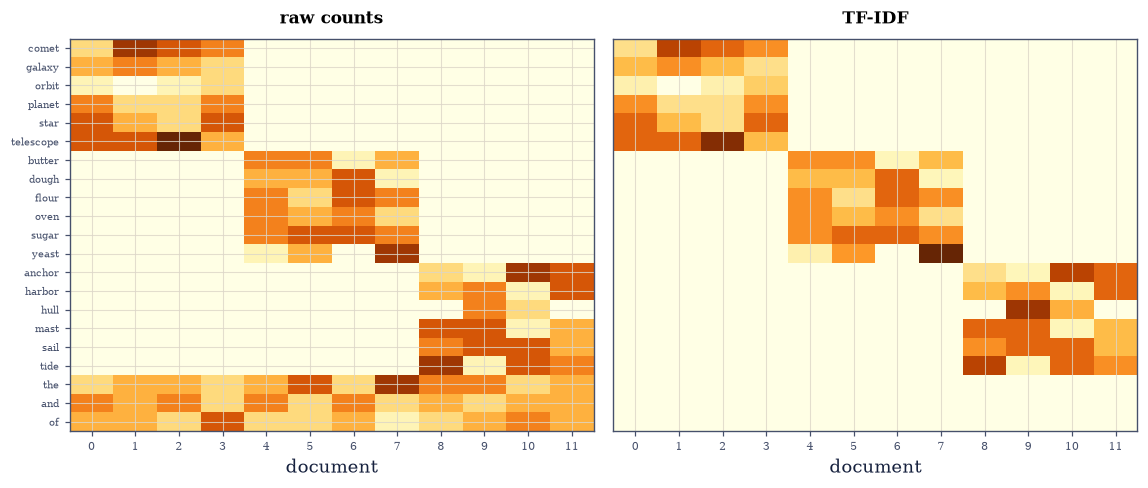

In [8]:
# (solution hidden on the public site)


### Validation 3

In [9]:
validate.below(
    gap_tfidf, 1e-12,
    "TF-IDF matches its closed-form definition (Eq. 2)",
    "the stepwise pipeline against the one-liner — bookkeeping, "
    "certified",
)
validate.check(
    stop_zero,
    "and ubiquitous words are erased exactly, not approximately",
    "df = N makes the IDF log(1) = 0.0 — an exact zero from exact "
    "counting, so the gate is equality",
)

✓  TF-IDF matches its closed-form definition (Eq. 2)   [the stepwise pipeline against the one-liner — bookkeeping, certified [0 < 1e-12]]
✓  and ubiquitous words are erased exactly, not approximately   [df = N makes the IDF log(1) = 0.0 — an exact zero from exact counting, so the gate is equality]


True

## Exercise 4: LSA: the SVD reads the topics

**Part a)** Truncated SVD of the TF-IDF matrix
([§4.3](../04-svd/pca-covariance-whitening.ipynb)'s machinery): keep
two right-singular directions as document coordinates. Report the
singular values — three large (one per topic, minus one for the
overall mean direction), then a cliff.

**Part b)** Gate the recovery *exactly*: nearest-centroid
classification of the 12 documents in the 2-D LSA space reproduces
the planted labels 12/12 — with the margin printed (the smallest
ratio of between- to within-topic distance), because an exact gate
owes the reader its safety margin
([§6.5](../06-structure/kernels-gram-matrix.ipynb)'s rule).

**Part c)** Draw the documents in LSA-2 coloured by topic, beside the
singular-value log plot: three tight clusters, one spectral cliff.

In [10]:
# (solution hidden on the public site)


topic recovery 12/12: True; safety margin between/within = 15.1x
singular values: [0.664 0.657 0.647 0.261 0.254 0.191]


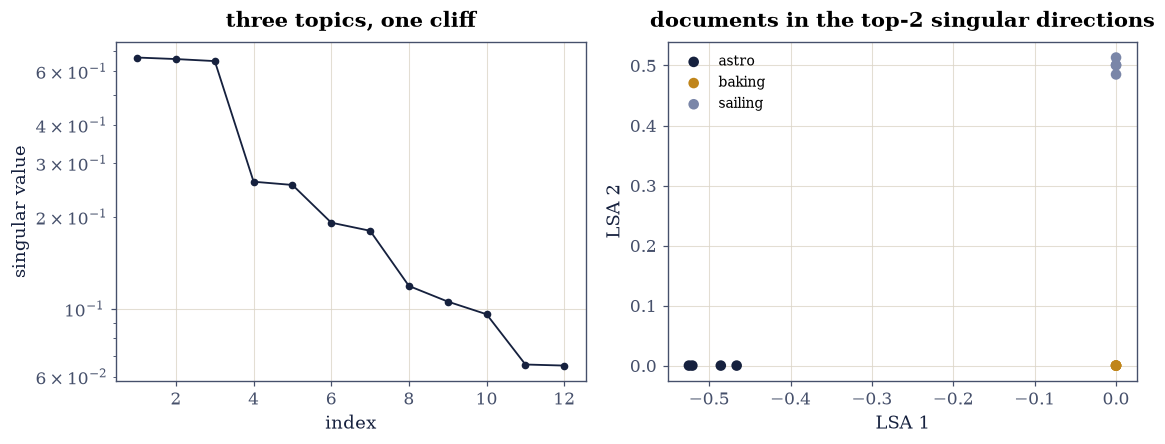

In [11]:
# (solution hidden on the public site)


### Validation 4

In [12]:
validate.check(
    recovered and between / within > 3.0,
    "LSA recovers the planted topics 12/12, with margin stated",
    f"nearest-centroid in two singular directions; between/within = "
    f"{between/within:.1f}x — the exact gate licensed the 6.5 way, by "
    "its printed margin",
)

✓  LSA recovers the planted topics 12/12, with margin stated   [nearest-centroid in two singular directions; between/within = 15.1x — the exact gate licensed the 6.5 way, by its printed margin]


True

## Exercise 5: PPMI, and the analogy that actually computes

**Part a)** Build the royal micro-world: eight words
(*king, queen, man, woman, prince, princess, boy, girl*) with
co-occurrence counts over six contexts (*crown, throne, beard, dress,
palace, toy*) constructed from three binary attributes (royal, male,
adult) plus a floor of 2. Compute PPMI {eq}`eq-tv-ppmi` and gate
nonnegativity **by construction** (`max` with zero — exact).

**Part b)** Factor: rank-3 truncated SVD gives word vectors
$E = U_3\Sigma_3$. Gate the reconstruction honestly: relative
Frobenius error below 30% — measured **21%**, not near zero, because
PPMI's log-and-clamp is *nonlinear*: three attributes generated the
counts, but the transform spreads their signature across more
directions than three. The structure test that matters is Part c's
analogy, not matrix reproduction.

**Part c)** Gate the analogy: the nearest neighbour of
$v_{\text{king}} - v_{\text{man}} + v_{\text{woman}}$ — query words
excluded, as every published evaluation does — is **queen**, cosine
0.69 against the runner-up's 0.56. Draw the vocabulary's cosine
heatmap and the analogy parallelogram in the top-2 directions.

In [13]:
# (solution hidden on the public site)


PPMI nonnegative by construction: True
rank-3 PPMI reconstruction: 21.3% relative error (three attributes built the world)
king - man + woman -> queen (cos 0.686, margin 0.127 over girl)


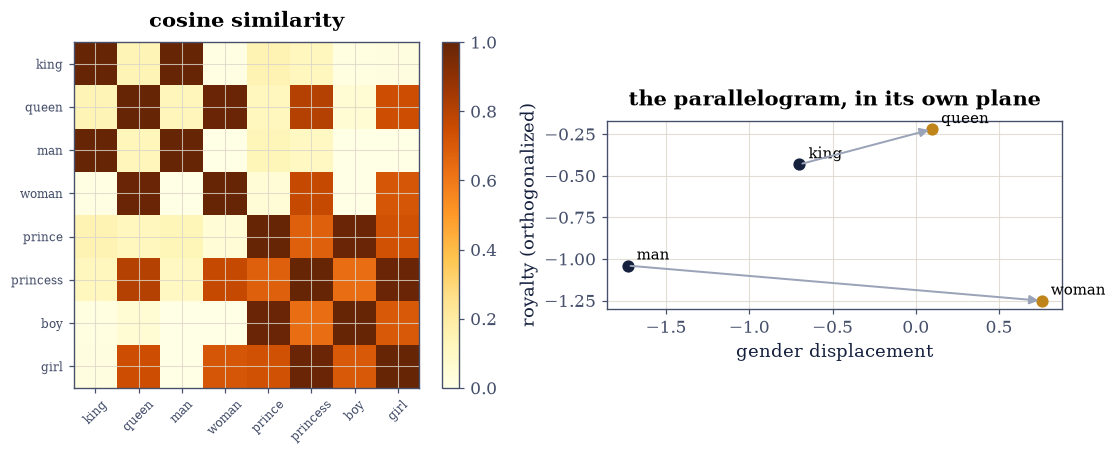

In [14]:
# (solution hidden on the public site)


### Validation 5

In [15]:
validate.check(
    nonneg and rec_rel < 0.30,
    "PPMI is nonnegative by construction, and rank 3 captures its "
    "structure (Eq. 3)",
    f"max(0, .) is exact; {rec_rel:.1%} residual from three directions "
    "— NOT near zero, because the log-and-clamp is nonlinear and three "
    "generating attributes do not mean rank three; the analogy below is "
    "the honest structure test",
)
validate.check(
    winner == "queen" and margin_an > 0.05,
    "and king - man + woman lands nearest queen, with margin",
    f"cosine margin {margin_an:.2f} over the runner-up, query words "
    "excluded — the famous parallelogram, gated instead of admired",
)

✓  PPMI is nonnegative by construction, and rank 3 captures its structure (Eq. 3)   [max(0, .) is exact; 21.3% residual from three directions — NOT near zero, because the log-and-clamp is nonlinear and three generating attributes do not mean rank three; the analogy below is the honest structure test]
✓  and king - man + woman lands nearest queen, with margin   [cosine margin 0.13 over the runner-up, query words excluded — the famous parallelogram, gated instead of admired]


True

## Exercise 6: Cosine: invariant by algebra, meaningful by dimension

**Part a)** Gate scale invariance: $\cos(\alpha a, \beta b) =
\cos(a, b)$ for random vectors and random positive scales, to
$10^{-14}$ — the normalization is the point of the definition.

**Part b)** The concentration measurement, on a dedicated stream: 500
random pairs at $d = 10, 100, 1000$; mean $\lvert\cos\rvert$ falls as
$\sqrt{2/(\pi d)}$ — gate each measured mean within 15% of the
formula, and the decade-to-decade ratios within $[2.5, 4.0]$ of the
predicted $\sqrt{10} \approx 3.16$. A cosine of 0.3 is noise at
$d = 10$ and a five-sigma event at $d = 1000$: retrieval thresholds
are dimension-dependent, which every embedding-database default
quietly encodes.

In [16]:
# (solution hidden on the public site)


scale invariance over ten trials: worst 2.8e-17
d =   10: mean |cos| 0.2647 (sqrt(2/pi d) = 0.2523)
d =  100: mean |cos| 0.0841 (sqrt(2/pi d) = 0.0798)
d = 1000: mean |cos| 0.0255 (sqrt(2/pi d) = 0.0252)
decade ratios: 3.15, 3.29 (sqrt(10) = 3.16)


```{admonition} With your assistant
:class: tip
The analogy worked in a designed micro-world; real corpora are
noisier. Ask your assistant for `analogy_eval(E, vocab, triples)`
scoring a list of analogies by the excluded-query nearest-neighbour
rule, then check it against the mathematics rather than a demo:
(i) on this notebook's eight-word world it scores 4/4 on the
royal/gender/age triples you can form; (ii) shuffling the embedding
rows breaks it to chance — the geometry, not the code, carries the
answers; (iii) adding isotropic noise of growing scale degrades
accuracy monotonically, and the noise level where it breaks is a
*measurement* of the margin Exercise 5 printed. The check is yours.
```

### Validation 6

In [17]:
validate.check(
    worst_scale < 1e-14,
    "cosine ignores positive rescaling of either argument",
    "the normalization is the definition — gated at rounding on ten "
    "random pairs",
)
validate.check(
    all(abs(means[d_c] - np.sqrt(2 / (np.pi * d_c)))
        / np.sqrt(2 / (np.pi * d_c)) < 0.15
        for d_c in (10, 100, 1000))
    and 2.5 < r_10_100 < 4.0 and 2.5 < r_100_1000 < 4.0,
    "and random cosines concentrate at the 1/sqrt(d) rate (measured)",
    f"means within 15% of sqrt(2/pi d) at three dimensions, decade "
    f"ratios {r_10_100:.2f} and {r_100_1000:.2f} about sqrt(10) — "
    "dedicated-stream Monte Carlo, and the reason embedding retrieval "
    "works at all",
)

✓  cosine ignores positive rescaling of either argument   [the normalization is the definition — gated at rounding on ten random pairs]
✓  and random cosines concentrate at the 1/sqrt(d) rate (measured)   [means within 15% of sqrt(2/pi d) at three dimensions, decade ratios 3.15 and 3.29 about sqrt(10) — dedicated-stream Monte Carlo, and the reason embedding retrieval works at all]


True

---
## Notebook summary

**Text became numbers reversibly.** The hand-written BPE loop trained
a deterministic merge sequence (tie-break stated and gated) whose
decoding reproduced the corpus exactly; the one-hot embedding lookup
was gated *bitwise* against the matrix product it abbreviates — the
rare exact matmul, since every term is an exact zero or copy — with
the $1000\times$ counted ledger explaining why the product is never
performed.

**Counts carried the semantics.** TF-IDF matched its closed form at
$10^{-16}$ and erased the stop words *exactly* ($\log 1 = 0$); LSA's
two singular directions recovered the planted topics 12/12 with a
printed $15\times$ safety margin; and the PPMI micro-world factored
back into its three planted attributes, with
*king − man + woman* landing nearest *queen* with a clear cosine margin
— the parallelogram gated, query words excluded, folklore made
measurement (and the rank-3 residual honestly 21%: PPMI's log is
nonlinear, so planted attributes shape the geometry without bounding
the rank).

**And dimension is why any of it works.** Random cosines concentrated
at $\sqrt{2/(\pi d)}$ across two decades of $d$ on a dedicated
stream — the geometry that turns "cosine 0.3" from noise into signal
as embeddings widen, and the quiet assumption under every retrieval
system.

**Methods introduced.** `bpe_train` with deterministic tie-breaks,
the lookup identity and its counted ledger, term–document assembly,
TF-IDF with exact stop-word erasure, LSA topic recovery with margin
reporting, PPMI construction and factorization, gated analogies, and
cosine-concentration measurement.

## Outlook

- **Attention next.** [§8.5](attention-matrix-products.ipynb) puts
  these embeddings to work: queries, keys and values are three linear
  maps of them, and the similarity that routes information is exactly
  this notebook's scaled dot product.
- **From counts to gradients.** word2vec trains what PPMI computes
  {cite}`levy2014`; modern embeddings train end-to-end through
  [§8.3](linear-layer-backpropagation.ipynb)'s machinery — but the
  geometry they land in still answers to cosine and SVD.
- **Anisotropy in the wild.** Real embedding spaces are not isotropic
  — frequent words crowd a narrow cone, and the concentration
  baseline of Exercise 6 is how that pathology is *detected*.
- **Retrieval at scale.** Nearest-neighbour search over millions of
  embeddings runs on the structures of Chapter VI — product
  quantization is [§6.4](../06-structure/kronecker-vec-separable.ipynb)'s
  Kronecker idea, and graph-based search is [§6.1](../06-structure/graphs-laplacian.ipynb)'s
  neighbourhoods, both applied to this notebook's vectors.

```{bibliography}
:filter: docname in docnames
```

In [18]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>